In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import numpy as np


In [2]:
# Set random seed for reproducibility
np.random.seed(1337)

# Generate fake data
n_frames = 1000
n_neurons = 200
X = np.random.poisson(lam=5, size=(n_frames, n_neurons))
look_back = 10
look_ahead = 10

# Generate fake classification labels (0 or 1) based on future frames
# For simplicity, let's say a high spike count in any neuron triggers a label '1'
threshold = 1050
Y = np.array([1 if np.any(X[i:i+look_ahead].sum(axis=1) > threshold) else 0 for i in range(n_frames - look_ahead)])
print(sum(Y))
X = X[:-look_ahead]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Data shape: {X.shape}")
print(f"Target shape: {Y.shape}")

436
Data shape: (990, 200)
Target shape: (990,)


In [3]:

class SimpleARClassifier:
    def __init__(self, lag, l1_ratio=0.5):
        self.lag = lag
        self.model = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=l1_ratio, random_state=42)
        self.scaler = StandardScaler()

    def prepare_data(self, X):
        n_samples, n_features = X.shape
        X_ar = np.hstack([X[i : n_samples - self.lag + i] for i in range(self.lag + 1)])
        return X_ar

    def fit(self, X, y):
        X_ar = self.prepare_data(X)
        X_ar_scaled = self.scaler.fit_transform(X_ar)
        self.model.fit(X_ar_scaled, y[self.lag :])

    def predict(self, X):
        X_ar = self.prepare_data(X)
        X_ar_scaled = self.scaler.transform(X_ar)
        return self.model.predict(X_ar_scaled)

AR Logistic Regression Accuracy: 0.4301


c:\Users\laurence\miniconda3\envs\subgoal\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


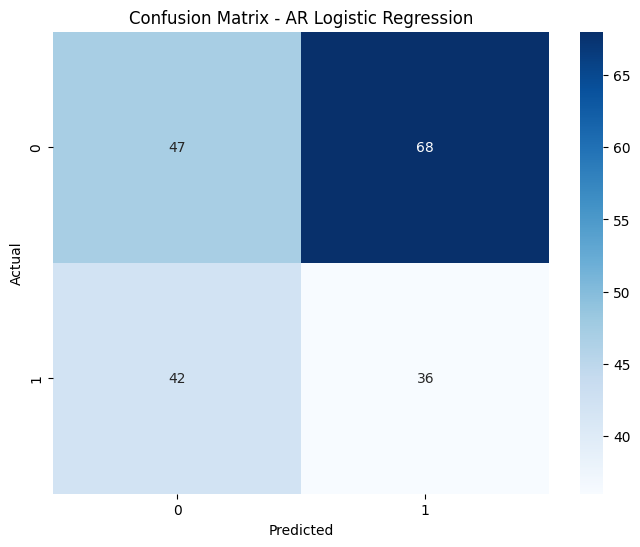

In [4]:
# Train and evaluate AR Logistic Regression
ar_model = SimpleARClassifier(lag=5)
ar_model.fit(X_train, y_train)

y_pred_ar = ar_model.predict(X_test)
accuracy_ar = accuracy_score(y_test[5:], y_pred_ar)
print(f"AR Logistic Regression Accuracy: {accuracy_ar:.4f}")

# Plot confusion matrix
cm_ar = confusion_matrix(y_test[5:], y_pred_ar)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ar, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - AR Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Naive Bayes Accuracy: 0.5960


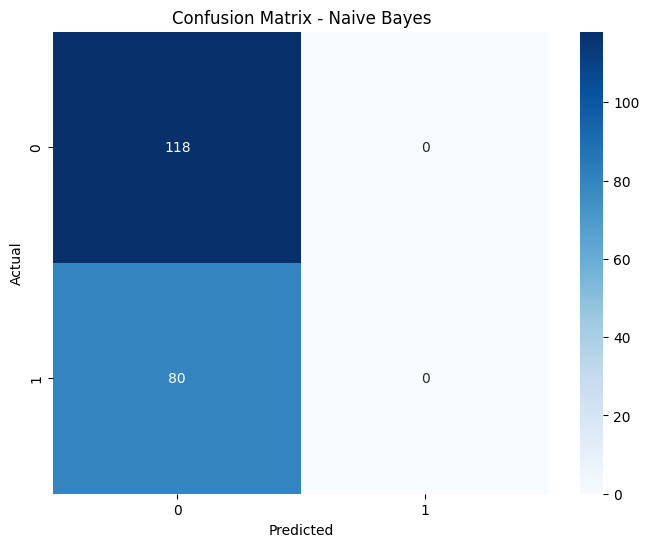

In [5]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import KBinsDiscretizer

def prepare_data_nb(X, n_recent=5, n_bins=5):
    X_recent = X[:, -n_recent:]
    discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
    X_binned = discretizer.fit_transform(X_recent)
    return X_binned, discretizer

# Prepare data for Naive Bayes
X_train_nb, discretizer = prepare_data_nb(X_train)
X_test_nb = discretizer.transform(X_test[:, -5:])

# Train and evaluate Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_nb, y_train)

y_pred_nb = nb_model.predict(X_test_nb)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb:.4f}")

# Plot confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()